# Tidal Dissipation  

Mapping Tidal Wave Dissipation needed for MOM6+CVMix tidal parameterization.

In [1]:
import xarray as xr
import xesmf as xe
import numpy as np
import matplotlib.colors as colors
import datetime

In [2]:
today = datetime.date.today().strftime("%y%m%d")
print(today)

260306


In [3]:
plot_opts = {'size':8, 'norm':colors.LogNorm(vmin=10e-7, vmax=3.0)}

### Original Forcing Data

In [4]:
src_ds = xr.open_dataset("/glade/campaign/cgd/oce/datasets/obs/tidal_dissipation/energy_new.nc")

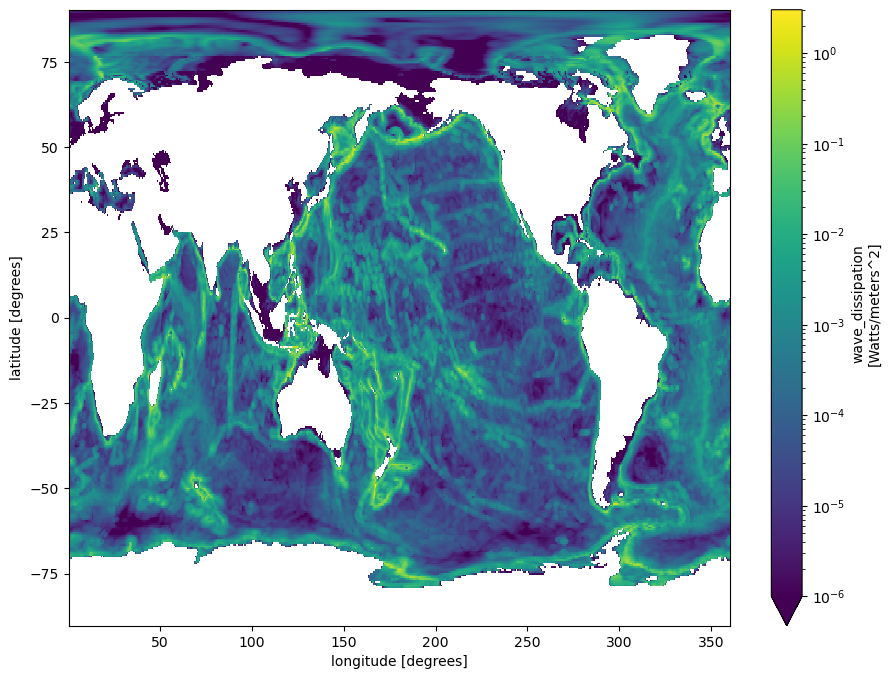

In [5]:
src_ds.wave_dissipation.plot(**plot_opts)

# Fix bad column in src

In [6]:
# Discard the first column in the src dataset. This bad column
# corresponds to 0.5 deg longitude. Then apply nearest_s2d mapping

regridder = xe.Regridder(
        src_ds.isel(longitude=slice(1,720)),
        src_ds,
        method='nearest_s2d',
        periodic=True,
    )

src_ds_fixed = regridder(src_ds.isel(longitude=slice(1,720))) 

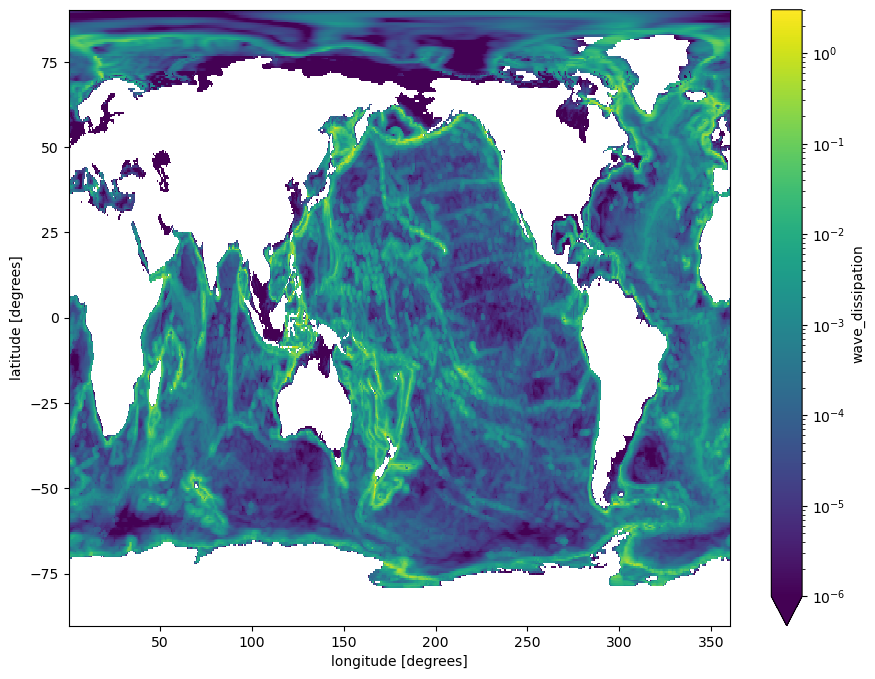

In [7]:
src_ds_fixed.wave_dissipation.plot(**plot_opts)

# Target Grid

In [8]:
dst_grid_path = "../mesh/tx2_3v3_grid.nc"
dst_grid = xr.open_dataset(dst_grid_path)
dst_grid = dst_grid.rename({'tlon': 'lon', 'tlat': 'lat', 'qlon':'lon_b', 'qlat': 'lat_b'})

### Conservative Regridding

In [9]:
# Conservative regridder from src grid to target grid.
regridder = xe.Regridder(
        src_ds_fixed,
        dst_grid,
        method='conservative',
        periodic=True,
    )

# Field mapped conservatively to the target grid
dst_fld = regridder(src_ds_fixed.wave_dissipation) 

/glade/u/apps/opt/miniforge/envs/npl-2026a/lib/python3.13/site-packages/xesmf/backend.py:57: UserWarning: Latitude is outside of [-90, 90]
  warnings.warn('Latitude is outside of [-90, 90]')


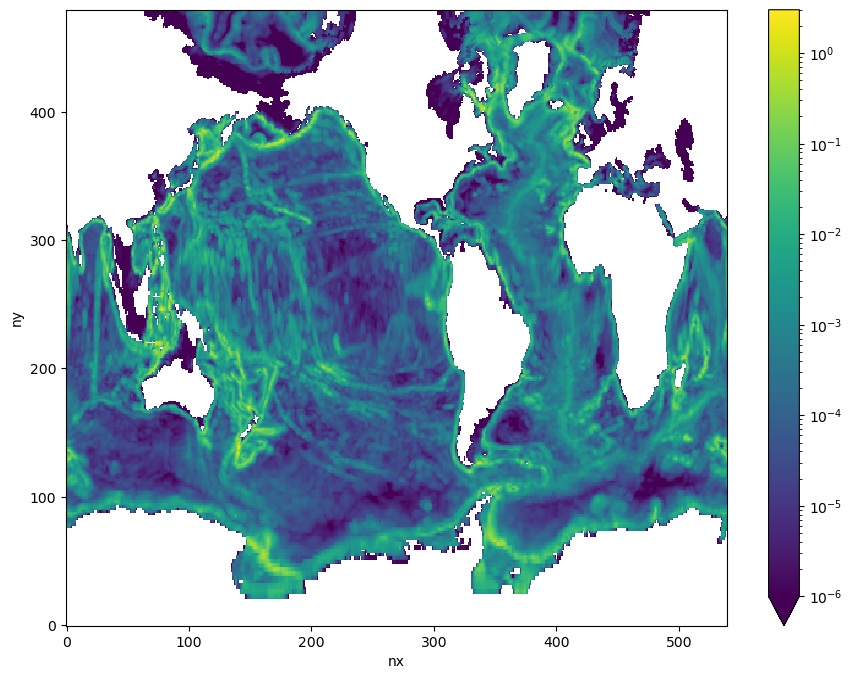

In [10]:
dst_fld.plot(**plot_opts)

### Reapply target mask:

In [11]:
dst_fld = xr.where(dst_grid.tmask>0, dst_fld, 0.0)

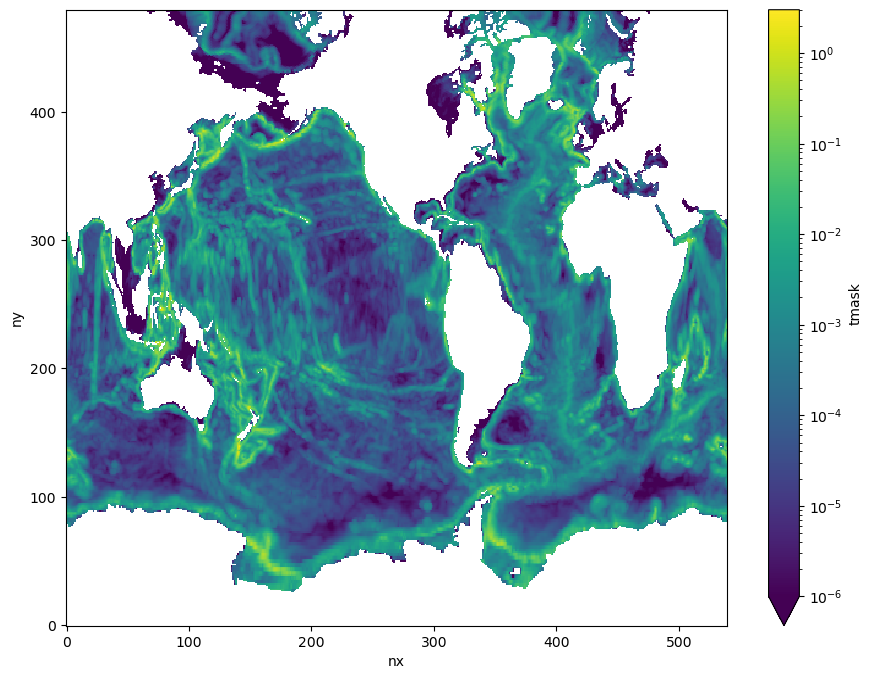

In [12]:
dst_fld.plot(**plot_opts)

### Save to file:

In [13]:
dst_ds = xr.Dataset(
    {"wave_dissipation": dst_fld},
    coords={
        'lon': dst_grid.lon, 
        'lat': dst_grid.lat, 
    },
    attrs = {
        'description': 'Estimated tidal dissipation data by S.R. Jayne. WHOI.',
        'author': 'Gustavo Marques (gmarques@ucar.edu)',
        'created': today
    }
)

fname = 'tidal_energy_tx2_3v3_conserve_{}.nc'.format(today)
dst_ds.to_netcdf(fname, engine="netcdf4", format="NETCDF3_64BIT_DATA",)

/glade/u/apps/opt/miniforge/envs/npl-2026a/lib/python3.13/site-packages/dask/config.py:786: FutureWarning: Dask configuration key 'allowed-failures' has been deprecated; please use 'distributed.scheduler.allowed-failures' instead
  warnings.warn(
